In [1]:
list.of.packages <- c("tidyverse","data.table","patchwork","stargazer","viridis")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpose



Please cite as: 


 Hlavac, Marek (2022).

In [2]:
T_bins_labels <- c("<=17°C","(17,21]","(21,23]","(23,25]","(25,27]","(27,29]","(29,31]","(31,33]",">33°C")
WB_bins_labels <- c("<=14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

# Dataframes

In [3]:
df_T_cells <- read_csv("./1_Grid_cell_date_data/output/df_T_cells_CDC_30_20_10.csv")
sprintf("%i x %i dataframe", nrow(df_T_cells), ncol(df_T_cells))
head(df_T_cells,2)

Rows: 173657 Columns: 9
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): T_i30_bin, T_i20_bin, T_i10_bin
dbl (6): Measured_date_CDC, cell_x, cell_y, T_i30, T_i20, T_i10

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "173657 x 9 dataframe"

Measured_date_CDC,cell_x,cell_y,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
42474,91.9,27.6,3.495833,4.510417,5.112500,<=17°C,<=17°C,<=17°C
42667,96.7,28.3,9.127778,8.314583,7.016667,<=17°C,<=17°C,<=17°C


In [4]:
max(df_T_cells$Measured_date_CDC)

[1] 44334

In [5]:
as.Date(max(df_T_cells$Measured_date_CDC), origin = "1900-01-01")

[1] "2021-05-20"

In [6]:
as.Date(43829, origin = "1900-01-01")

[1] "2020-01-01"

In [7]:
df_T_cells_m <- df_T_cells %>%
                        mutate(Measured_date = as.Date("1900-01-01") + Measured_date_CDC, 
                               Measured_month =month(Measured_date))%>%
                        filter(Measured_date_CDC <= 43828)
sprintf("%i x %i dataframe", nrow(df_T_cells_m), ncol(df_T_cells_m))
head(df_T_cells_m,2)

[1] "127695 x 11 dataframe"

Measured_date_CDC,cell_x,cell_y,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,Measured_date,Measured_month
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<date>,<int>
42474,91.9,27.6,3.495833,4.510417,5.112500,<=17°C,<=17°C,<=17°C,2016-04-16,4
42667,96.7,28.3,9.127778,8.314583,7.016667,<=17°C,<=17°C,<=17°C,2016-10-26,10


In [8]:
df_WB_cells <- read_csv("./1_Grid_cell_date_data/output/df_WB_cells_CDC_30_20_10.csv")
sprintf("%i x %i dataframe", nrow(df_WB_cells), ncol(df_WB_cells))
head(df_WB_cells,2)

Rows: 126725 Columns: 9
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): WB_i30_bin, WB_i20_bin, WB_i10_bin
dbl (6): Measured_date_CDC, cell_x, cell_y, WB_i30, WB_i20, WB_i10

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "126725 x 9 dataframe"

Measured_date_CDC,cell_x,cell_y,WB_i30,WB_i20,WB_i10,WB_i30_bin,WB_i20_bin,WB_i10_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
42474,91.75,27.50,5.580556,6.608333,7.283333,<=14°C,<=14°C,<=14°C
42660,96.75,28.25,10.943056,10.629167,9.354167,<=14°C,<=14°C,<=14°C


In [9]:
df_WB_cells_m <- df_WB_cells %>%
                        mutate(Measured_date = as.Date("1900-01-01") + Measured_date_CDC, 
                               Measured_month =month(Measured_date))%>%
                        filter(Measured_date_CDC <= 43828)
sprintf("%i x %i dataframe", nrow(df_WB_cells_m), ncol(df_WB_cells_m))
head(df_WB_cells_m,2)

[1] "94089 x 11 dataframe"

Measured_date_CDC,cell_x,cell_y,WB_i30,WB_i20,WB_i10,WB_i30_bin,WB_i20_bin,WB_i10_bin,Measured_date,Measured_month
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<date>,<int>
42474,91.75,27.50,5.580556,6.608333,7.283333,<=14°C,<=14°C,<=14°C,2016-04-16,4
42660,96.75,28.25,10.943056,10.629167,9.354167,<=14°C,<=14°C,<=14°C,2016-10-19,10


# Air temperature bar plot

In [10]:
df_bar_plot_T <- df_T_cells_m %>%
                        group_by(Measured_month)%>%
                        mutate(N_month=n())%>%
                        ungroup()%>%
                        filter(!is.na(T_i30_bin))%>%
                        group_by(Measured_month,T_i30_bin)%>%
                        summarize(value=n(),
                                  N_month=first(N_month))%>%
                        ungroup()%>%
                        mutate(T_i30_bin=factor(T_i30_bin,levels=T_bins_labels),
                               perc=value/N_month,
                               Perc=round(perc*100)
                               )
head(df_bar_plot_T)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Measured_month and T_i30_bin.
ℹ Output is grouped by Measured_month.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Measured_month, T_i30_bin))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


Measured_month,T_i30_bin,value,N_month,perc,Perc
<int>,<fct>,<int>,<int>,<dbl>,<dbl>
1,"(17,21]",286,1605,0.17819315,18
1,"(21,23]",24,1605,0.01495327,1
1,"(23,25]",32,1605,0.01993769,2
1,<=17°C,1263,1605,0.78691589,79
2,"(17,21]",2418,8921,0.27104585,27
2,"(21,23]",749,8921,0.08395920,8


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


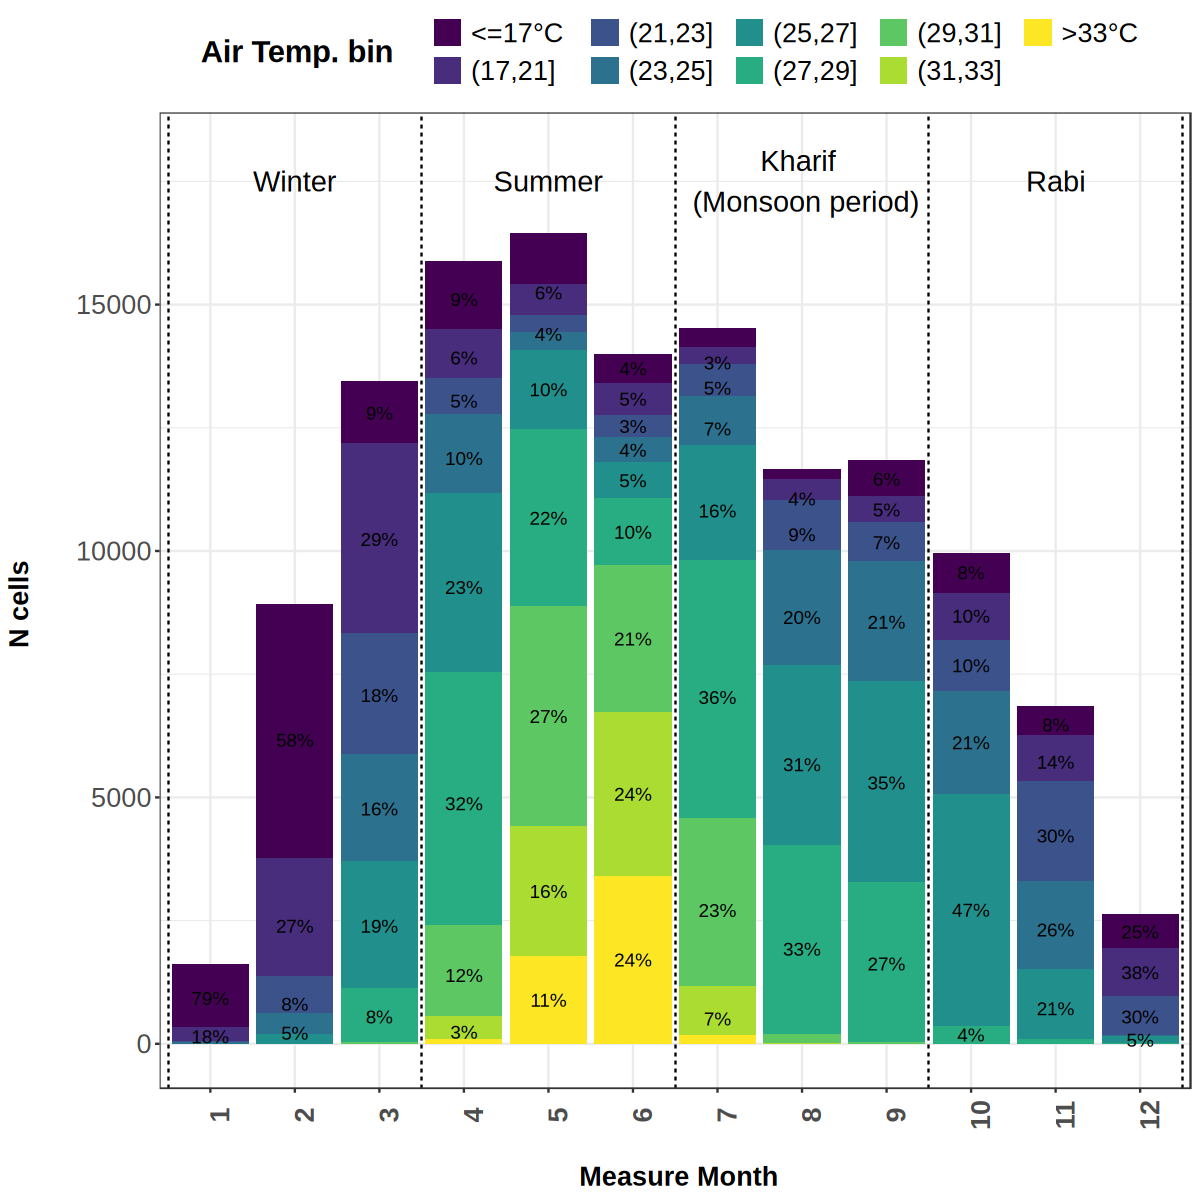

In [11]:
options(repr.plot.width=10, repr.plot.height=10, scipen=9999)

plot_T_month <- ggplot(df_bar_plot_T,aes(x=as.factor(Measured_month),y=value,fill=T_i30_bin))+
                            geom_bar(stat="identity") +    
                            theme_bw() +
                            labs(x="\n Measure Month",y="N cells \n")+
                            scale_fill_manual(values=viridis(9),
                                              name="Air Temp. bin")+
                            geom_text(data=df_bar_plot_T%>%filter(Perc>2),
                                      aes(x = as.factor(Measured_month), label = paste0(Perc,'%')),
                                      colour = 'black', position=position_stack(vjust=0.5))+
                            coord_cartesian(y=c(0,18000))+
                            geom_vline(xintercept= 0.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 3.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 6.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 9.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 12.5, linetype="dashed", size=0.5)+
                            annotate("text", x = 2, y = 17500, label = "Winter",angle = 0, size=6) +
                            annotate("text", x = 5, y = 17500, label = "Summer",angle = 0, size=6) +
                            annotate("text", x = 8, y = 17500, label = "Kharif \n (Monsoon period)",angle = 0, size=6) +
                            annotate("text", x = 11, y = 17500, label = "Rabi",angle = 0, size=6) +
                            theme(legend.position="top",
                                  legend.title = element_text(size = 18,face ="bold"),
                                  legend.text = element_text(size = 16),
                                  axis.text.x = element_text(size = 16,face ="bold",angle=90),
                                  axis.text.y = element_text(size = 16),
                                  axis.title.x = element_text(size = 16, hjust = 0.5,face ="bold"),
                                  axis.title.y = element_text(size = 16, hjust = 0.5,face ="bold")
                                              )
plot_T_month 

# Wet-bulb temperature bar plot

In [12]:
df_bar_plot_WB <- df_WB_cells_m %>%
                        group_by(Measured_month)%>%
                        mutate(N_month=n())%>%
                        ungroup()%>%
                        filter(!is.na(WB_i30_bin))%>%
                        group_by(Measured_month,WB_i30_bin)%>%
                        summarize(value=n(),
                                  N_month=first(N_month))%>%
                        ungroup()%>%
                        mutate(WB_i30_bin=factor(WB_i30_bin,levels = WB_bins_labels),
                               perc=value/N_month,
                               Perc=round(perc*100)
                               )
head(df_bar_plot_WB)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Measured_month and WB_i30_bin.
ℹ Output is grouped by Measured_month.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Measured_month, WB_i30_bin))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


Measured_month,WB_i30_bin,value,N_month,perc,Perc
<int>,<fct>,<int>,<int>,<dbl>,<dbl>
1,"(14,16]",415,1168,0.355308219,36
1,"(16,18]",119,1168,0.101883562,10
1,"(18,20]",49,1168,0.041952055,4
1,"(20,22]",17,1168,0.014554795,1
1,"(22,24]",7,1168,0.005993151,1
1,<=14°C,561,1168,0.480308219,48


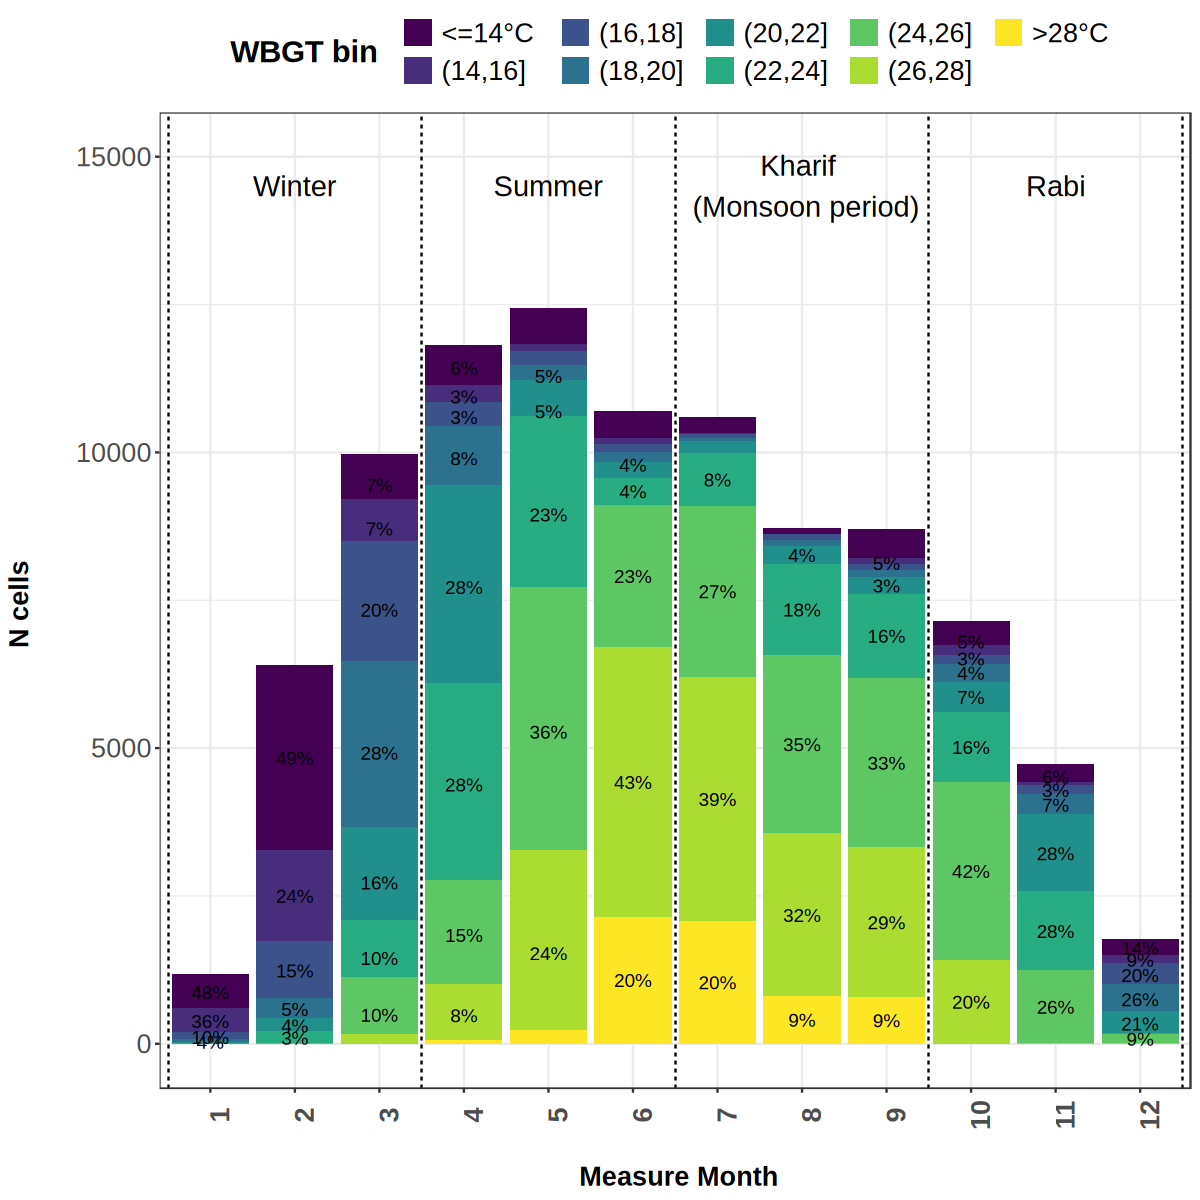

In [13]:
options(repr.plot.width=10, repr.plot.height=10, scipen=9999)

plot_WB_month <- ggplot(df_bar_plot_WB,aes(x=as.factor(Measured_month),y=value,fill=WB_i30_bin))+
                            geom_bar(stat="identity") +    
                            theme_bw() +
                            labs(x="\n Measure Month",y="N cells \n")+
                            scale_fill_manual(values=viridis(9),
                                              name="WBGT bin")+
                            geom_text(data=df_bar_plot_WB%>%filter(Perc>2),
                                      aes(x = as.factor(Measured_month), label = paste0(Perc,'%')),
                                      colour = 'black', position=position_stack(vjust=0.5))+
                            coord_cartesian(y=c(0,15000))+
                            geom_vline(xintercept= 0.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 3.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 6.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 9.5, linetype="dashed", size=0.5)+
                            geom_vline(xintercept= 12.5, linetype="dashed", size=0.5)+
                            annotate("text", x = 2, y = 14500, label = "Winter",angle = 0, size=6) +
                            annotate("text", x = 5, y = 14500, label = "Summer",angle = 0, size=6) +
                            annotate("text", x = 8, y = 14500, label = "Kharif \n (Monsoon period)",angle = 0, size=6) +
                            annotate("text", x = 11, y = 14500, label = "Rabi",angle = 0, size=6) +
                            theme(legend.position="top",
                                  legend.title = element_text(size = 18,face ="bold"),
                                  legend.text = element_text(size = 16),
                                  axis.text.x = element_text(size = 16,face ="bold",angle=90),
                                  axis.text.y = element_text(size = 16),
                                  axis.title.x = element_text(size = 16, hjust = 0.5,face ="bold"),
                                  axis.title.y = element_text(size = 16, hjust = 0.5,face ="bold")
                                              )
plot_WB_month 

# Both

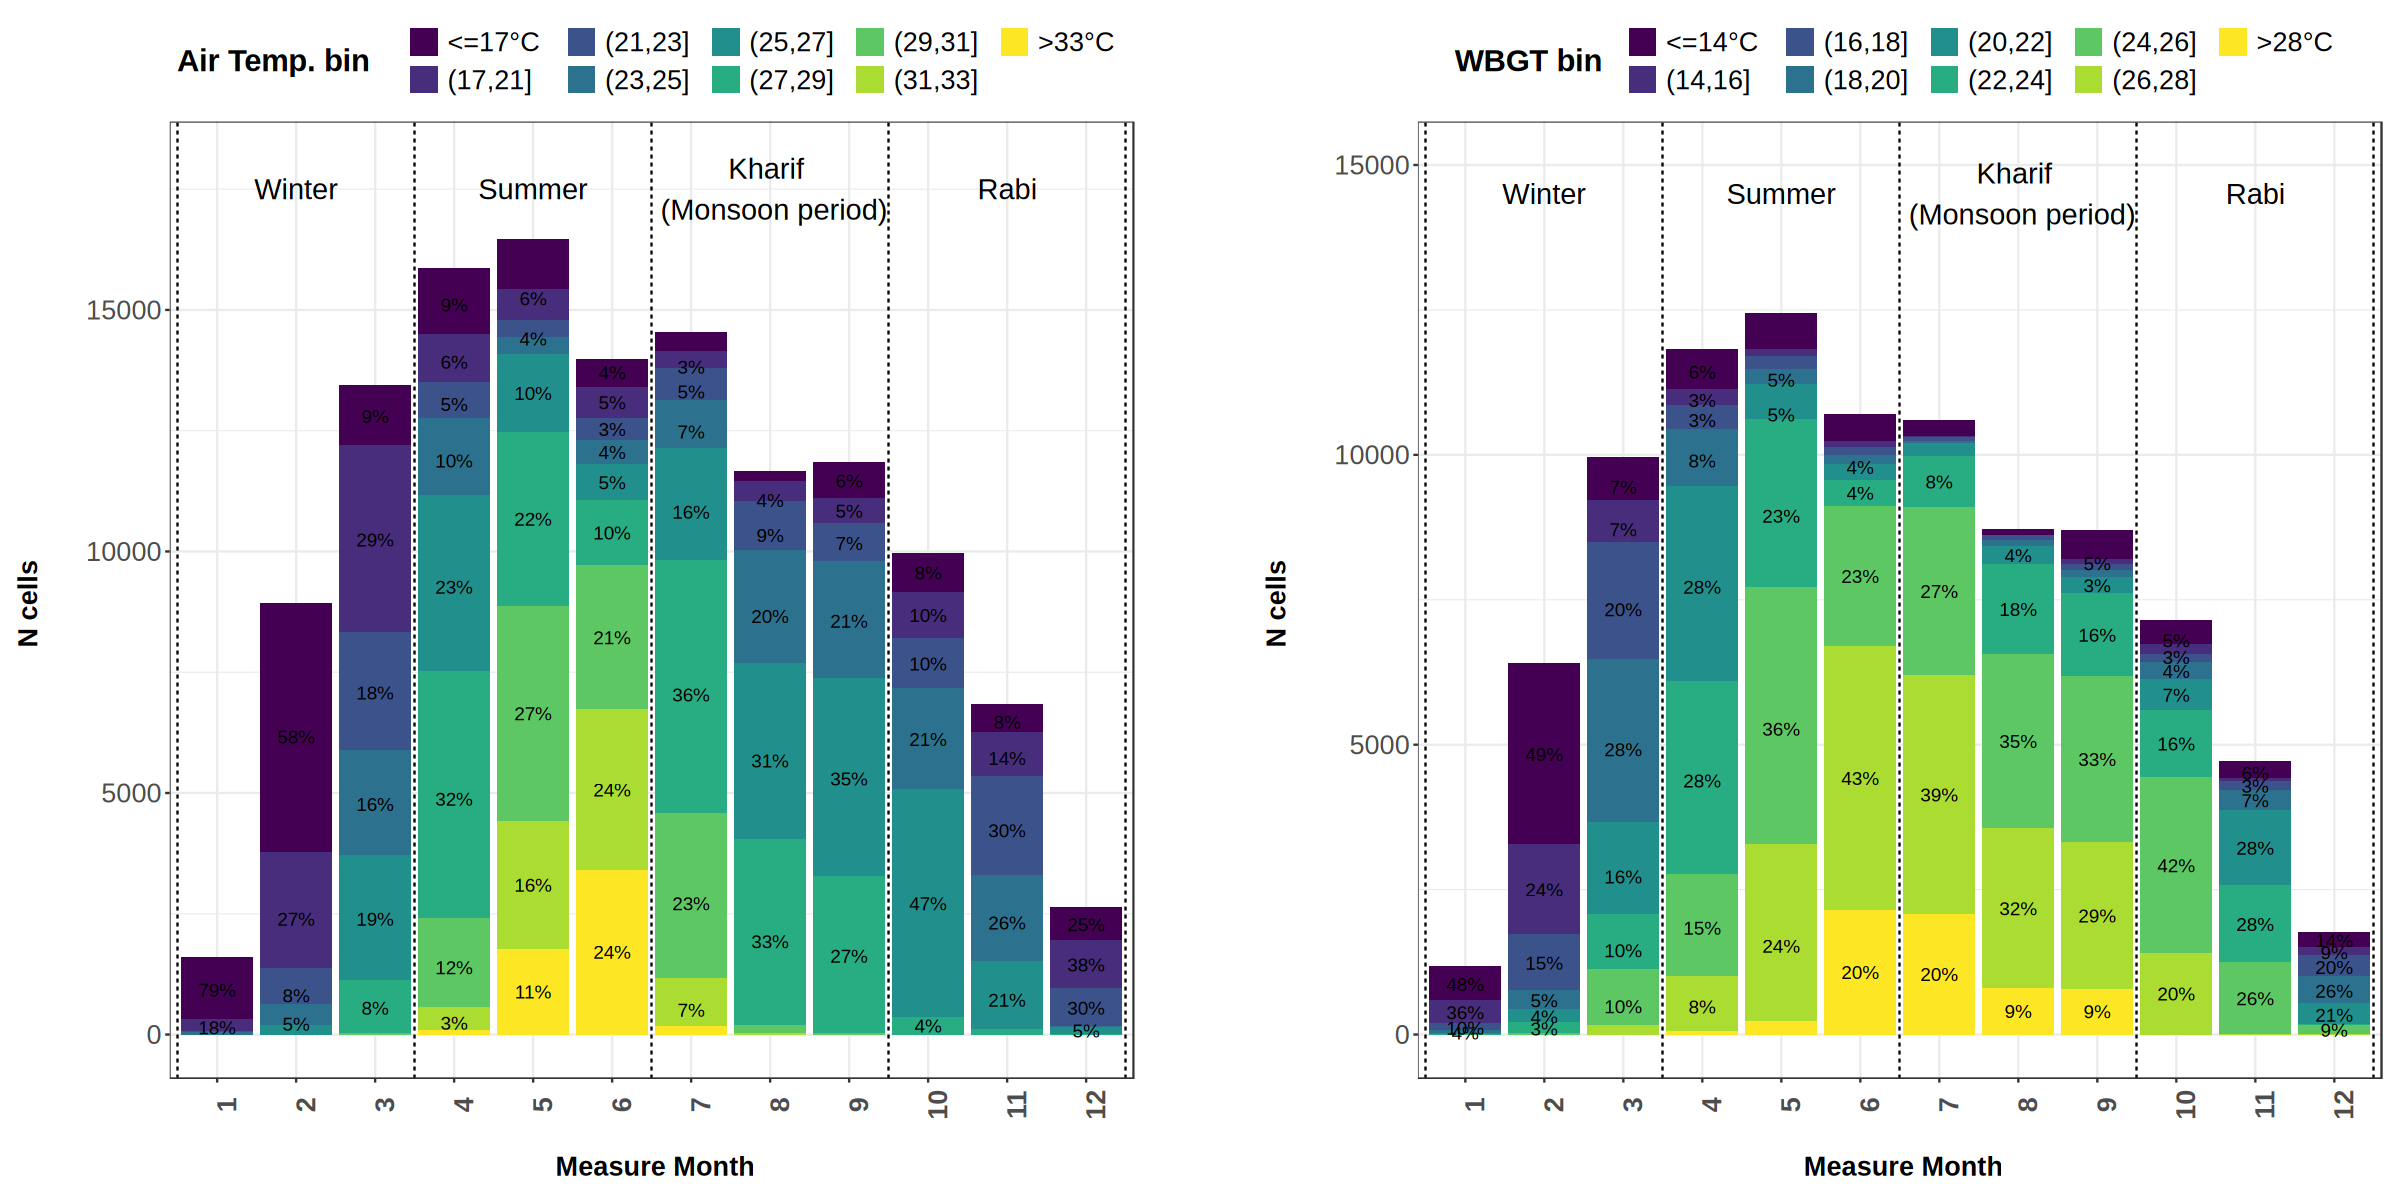

In [14]:
options(repr.plot.width=20, repr.plot.height=10, scipen=9999)

plot_both <- plot_T_month + plot_spacer() + plot_WB_month + plot_layout(widths=c(10,1,10))
plot_both

In [15]:
ggsave("./3_output/img/histo_monthly_means_cells.png", width=22, height=10, plot_both)